In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the dataset
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [2]:
# Shape: rows and columns
print("Shape:")
print(df.shape)
# Column names
print("\nColumn names:")
print(df.columns.tolist())
# Data types
print("\nData types:")
print(df.dtypes)
# Missing values per column
print("\nMissing values:")
print(df.isna().sum())

Shape:
(7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values:
customerID 

In [5]:
# Count values in TotalCharges that are empty or only whitespace
empty_or_whitespace_count = df["TotalCharges"].astype(str).str.strip().eq("").sum()

print("Empty or whitespace values in TotalCharges:", empty_or_whitespace_count)


Empty or whitespace values in TotalCharges: 11


In [ ]:
df["TotalCharges"] = df["TotalCharges"].replace(r"^\s*$", 0, regex=True)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

0


In [9]:
# Check dtype of TotalCharges
print("TotalCharges dtype:")
print(df["TotalCharges"].dtype)

# Confirm missing values
print("\nMissing values in TotalCharges:")
print(df["TotalCharges"].isna().sum())

# Optional: confirm no empty/whitespace-only strings remain
print("\nEmpty or whitespace-only values in TotalCharges:")
print(df["TotalCharges"].astype(str).str.strip().eq("").sum())

TotalCharges dtype:
float64

Missing values in TotalCharges:
0

Empty or whitespace-only values in TotalCharges:
0


In [10]:
# Check duplicate rows in the whole dataset
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows in the whole dataset:", duplicate_count)

Number of duplicate rows in the whole dataset: 0


In [11]:
# Count and percentage distribution of Churn
churn_distribution = pd.DataFrame({
    "count": df["Churn"].value_counts(),
    "percentage": df["Churn"].value_counts(normalize=True) * 100
})

churn_distribution["percentage"] = churn_distribution["percentage"].round(2)

print(churn_distribution)

       count  percentage
Churn                   
No      5174       73.46
Yes     1869       26.54


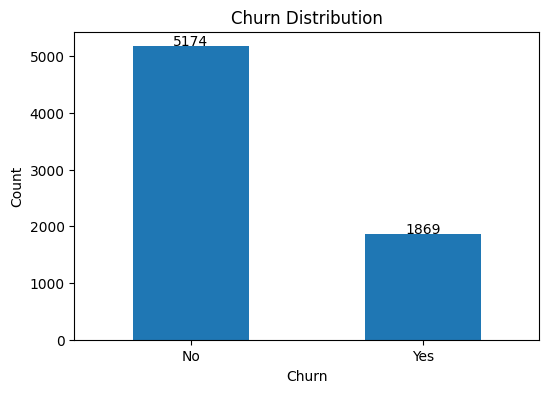

In [12]:
# Count Churn values
churn_counts = df["Churn"].value_counts()

# Bar chart
plt.figure(figsize=(6, 4))
churn_counts.plot(kind="bar")

# Labels and title
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.xticks(rotation=0)

# Show counts on top of bars
for i, value in enumerate(churn_counts):
    plt.text(i, value + 10, str(value), ha="center")

plt.show()

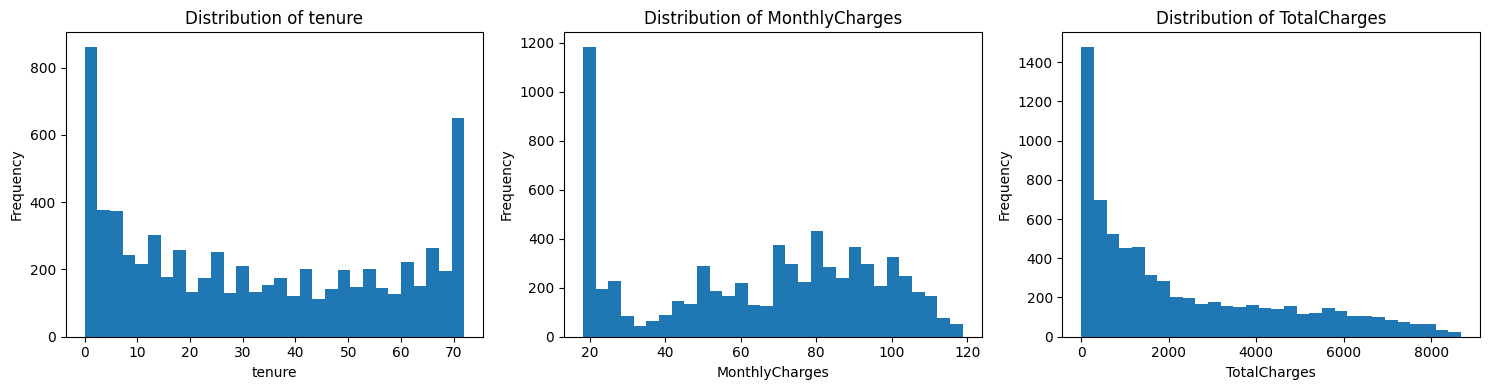

In [13]:
# Numerical columns
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# Create 3 histograms side by side
plt.figure(figsize=(15, 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [15]:
# Value counts for Contract column
contract_counts = df["Contract"].value_counts()

print(contract_counts)

contract_distribution = pd.DataFrame({
    "count": df["Contract"].value_counts(),
    "percentage": (df["Contract"].value_counts(normalize=True) * 100).round(2)
})

print(contract_distribution)

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64
                count  percentage
Contract                         
Month-to-month   3875       55.02
Two year         1695       24.07
One year         1473       20.91


Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


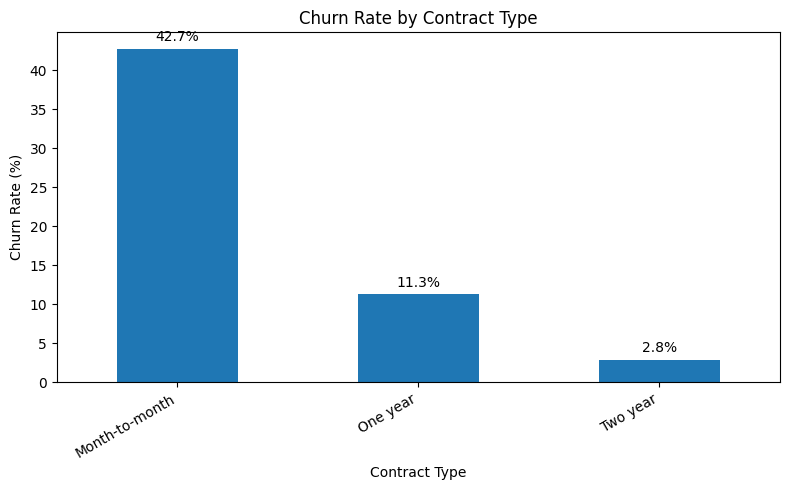

In [16]:
# Calculate churn rate by contract type
churn_rate_contract = (
    df.groupby("Contract")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print(churn_rate_contract)

# Plot bar chart
plt.figure(figsize=(8, 5))
churn_rate_contract.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")

# Show percentage labels on bars
for i, value in enumerate(churn_rate_contract):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64


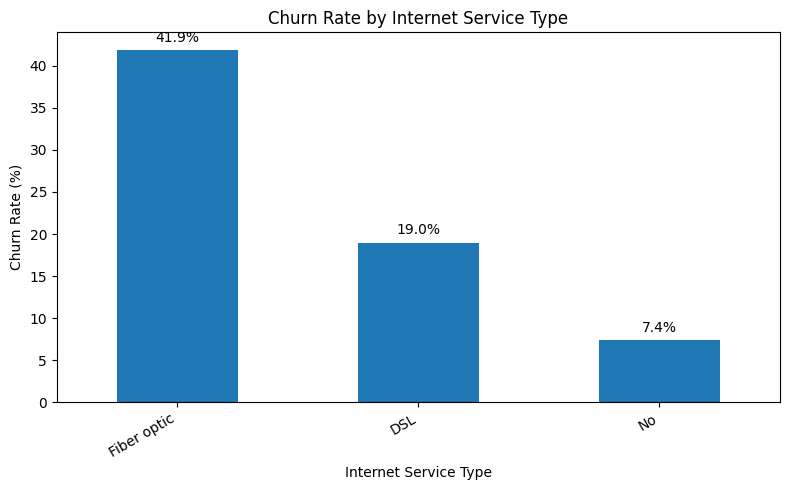

In [17]:
# Calculate churn rate by internet service type
churn_rate_internet = (
    df.groupby("InternetService")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print(churn_rate_internet)

# Plot bar chart
plt.figure(figsize=(8, 5))
churn_rate_internet.plot(kind="bar")

plt.title("Churn Rate by Internet Service Type")
plt.xlabel("Internet Service Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")

# Show percentage labels on bars
for i, value in enumerate(churn_rate_internet):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

In [18]:
# Average tenure for churned vs non-churned customers
avg_tenure_churn = df.groupby("Churn")["tenure"].mean()

print(avg_tenure_churn)

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64
